# **FICO® Xpress MoselPy - Chapter J: Public Services and Utilities**

***public_services.ipynb*** - Public services and utilities problems from the Xpress Applications Book - water supply network flow, CCTV camera placement, electoral redistricting, road gritting circuits, tax office location, and hospital efficiency analysis, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
import moselpy as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/public_services"
DATA   = "data/public_services"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Public services and utilities problems

This notebook covers six LP and IP examples from Chapter J of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples include water supply network flow, CCTV camera placement, electoral redistricting, road gritting circuits, tax office location, and hospital efficiency analysis.

> **Mosel source files:** [`models/public_services/`](models/public_services/) &nbsp;|&nbsp; **Data files:** [`data/public_services/`](data/public_services/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_10)

### MoselPy features demonstrated in this chapter

- **`ARCS: range` auto-populated from arc data**: PIPE dict keys populate the ARCS range automatically (J-1).
- **Dynamic sparse array with `exists()`**: STREET and LEN adjacency matrices populated from sparse Python dicts (J-2, J-4).
- **Python preprocessing passed to Mosel**: J-3 enumerates all valid electoral districts in Python using a recursive algorithm, then passes the computed `DISTR` and `MAJ` arrays to a MIP-only Mosel model via `input_data`.
- **Eulerian circuit extracted in Python**: J-4 solves the arc-frequency LP in Mosel, then runs Hierholzer's algorithm in Python to extract the tour from the returned arc usage dict.
- **Floyd-Warshall inside Mosel**: distance preprocessing runs inside a single `execute_model` call (J-5).
- **Named `linctr` reassigned in a loop**: DEA model constraints redefined per hospital; efficiency scores collected into `pd.Series` (J-6).

## J-1 Water supply network (LP)

*Applications Book Chapter J, Example 1*

> **Mosel model:** [`j1water_p.mos`](models/public_services/j1water_p.mos)

A water transport network connects a source node (a reservoir, node 11) to a sink node (a city, node 12) via 10 intermediate nodes. Twenty pipes with individual capacities carry water. The model maximizes total flow from source to sink subject to flow conservation and capacity constraints.

The `ARCS: range` in Mosel is automatically populated from the `PIPE` data dict keys, so no arc count needs to be specified explicitly.

**Sets:** $\text{ARCS}$ (auto-populated from PIPE), $\text{NODES} = 1..12$

**Parameters:** $\text{PIPE}_{a,1}$, $\text{PIPE}_{a,2}$ - from/to nodes; $\text{CAP}_a$ - pipe capacity; $\text{SOURCE}=11$, $\text{SINK}=12$

**Decision variables:** $\mathit{flow}_a \geq 0$ - flow on arc $a$

$$
\begin{align*}
\text{maximize}   \quad & \sum_{a:\, \text{PIPE}_{a,2}=12} \mathit{flow}_a \\
\text{subject to} \quad & \sum_{a:\, \text{PIPE}_{a,1}=n} \mathit{flow}_a = \sum_{a:\, \text{PIPE}_{a,2}=n} \mathit{flow}_a \quad \forall\, n \neq \{11,12\} \\
                          & \mathit{flow}_a \leq \text{CAP}_a \quad \forall\, a
\end{align*}
$$

Define arcs as a dict with `(arc_index, 1)` and `(arc_index, 2)` keys for the from- and to-nodes, plus `CAP` as a 1-indexed capacity dict. The `ARCS: range` in Mosel auto-extends to cover all arc indices present in `PIPE`.

In [ ]:
pipes_raw = [
    (1,3),(1,5),(1,6),(2,5),(2,6),(3,4),(3,5),(4,8),(4,9),(5,8),
    (5,9),(5,10),(6,7),(7,9),(7,10),(8,12),(9,12),(10,12),(11,1),(11,2),
]
PIPE = {}
for a, (frm, to) in enumerate(pipes_raw, start=1):
    PIPE[(a, 1)] = frm
    PIPE[(a, 2)] = to

CAP = {a: c for a, c in enumerate(
    [20,15,12,6,22,15,10,7,10,10,15,15,22,10,10,18,15,20,35,25], start=1
)}
SOURCE, SINK = 11, 12

pipe_df = pd.DataFrame(
    {"From": [PIPE[(a,1)] for a in range(1,21)],
     "To":   [PIPE[(a,2)] for a in range(1,21)],
     "Cap":  [CAP[a]       for a in range(1,21)]},
    index=range(1, 21),
)
pipe_df.index.name = "Arc"
print(pipe_df.to_string())

     From  To  Cap
Arc               
1       1   3   20
2       1   5   15
3       1   6   12
4       2   5    6
5       2   6   22
6       3   4   15
7       3   5   10
8       4   8    7
9       4   9   10
10      5   8   10
11      5   9   15
12      5  10   15
13      6   7   22
14      7   9   10
15      7  10   10
16      8  12   18
17      9  12   15
18     10  12   20
19     11   1   35
20     11   2   25


Use the single execution command. `PIPE` and `CAP` are passed via `input_data`; `SOURCE` and `SINK` are overridden via `exec_params` even though they match the model defaults, to show the pattern explicitly. The `ARCS` range auto-populates from the `PIPE` dict keys.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/j1water_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:",
                 "SOURCE": SOURCE, "SINK": SINK},
    input_data={"PIPE": PIPE, "CAP": CAP},
)

if model.prob_status.is_solution_available:
    obj_val_j1 = output["obj_val"]
    sol_flow   = output["sol_flow"]

    print(f"Maximum total flow: {obj_val_j1:.0f}")
    print()
    print(f"{'Arc':>4}  {'From':>5} {'To':>5} {'Flow':>6} {'Cap':>5}")
    for a in range(1, 21):
        f = sol_flow.get(a, 0)
        if f > 0.01:
            print(f"  {a:>2}  {PIPE[(a,1)]:>5} {PIPE[(a,2)]:>5} {f:>6.1f} {CAP[a]:>5}")
else:
    print(f"No solution found ({model.prob_status})")

Maximum total flow: 52

 Arc   From    To   Flow   Cap
   1      1     3   11.0    20
   2      1     5   15.0    15
   3      1     6    9.0    12
   4      2     5    6.0     6
   5      2     6   11.0    22
   6      3     4    7.0    15
   7      3     5    4.0    10
   8      4     8    7.0     7
  10      5     8   10.0    10
  11      5     9    5.0    15
  12      5    10   10.0    15
  13      6     7   20.0    22
  14      7     9   10.0    10
  15      7    10   10.0    10
  16      8    12   17.0    18
  17      9    12   15.0    15
  18     10    12   20.0    20
  19     11     1   35.0    35
  20     11     2   17.0    25


Network diagram showing flow on each pipe. Node size reflects the number of incident pipes; arrow thickness and label show the flow.

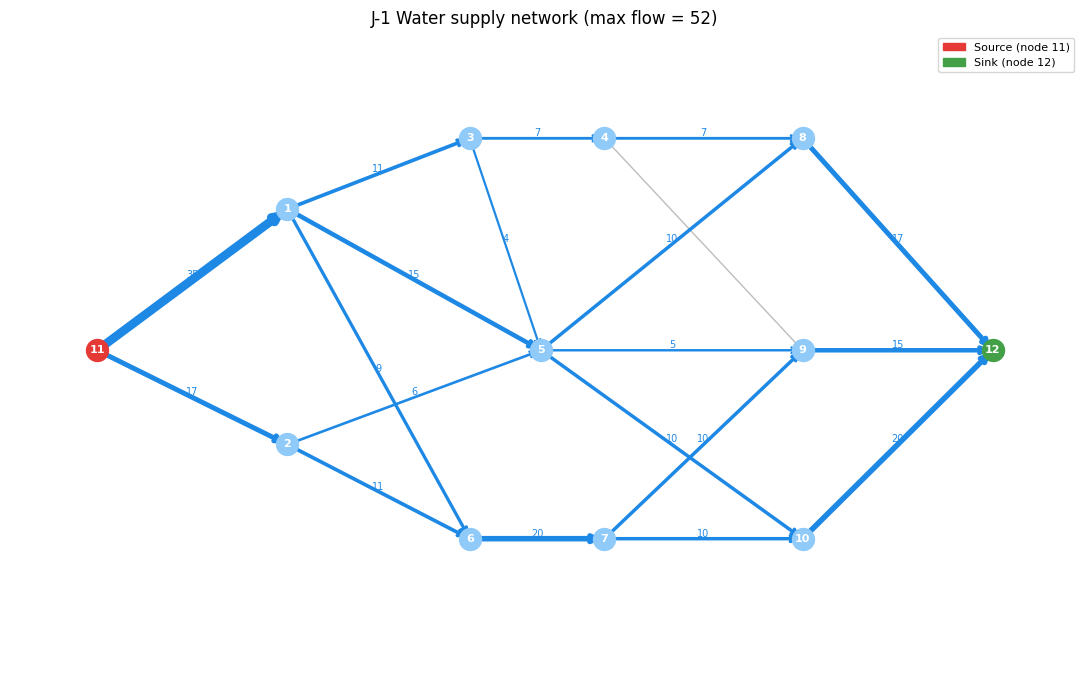

In [ ]:
if "sol_flow" in locals():
    # Node coordinates from original data (POS array)
    pos = {1:(30,35),2:(30,15),3:(53,41),4:(70,41),5:(62,23),6:(53,7),
           7:(70,7),8:(95,41),9:(95,23),10:(95,7),11:(6,23),12:(119,23)}

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.set_xlim(-5, 130); ax.set_ylim(-5, 50)

    # Draw arcs
    for a in range(1, 21):
        frm, to = PIPE[(a,1)], PIPE[(a,2)]
        fx, fy = pos[frm]; tx, ty = pos[to]
        f = sol_flow.get(a, 0)
        color = "#1E88E5" if f > 0.5 else "#BDBDBD"
        lw = 1 + f * 0.15
        ax.annotate("", xy=(tx, ty), xytext=(fx, fy),
                    arrowprops=dict(arrowstyle="->", color=color, lw=lw,
                                   connectionstyle="arc3,rad=0.0"))
        if f > 0.5:
            mx, my = (fx+tx)/2, (fy+ty)/2
            ax.text(mx, my, f"{f:.0f}", fontsize=7, color="#1E88E5",
                    ha="center", va="bottom")

    # Draw nodes
    for n, (x, y) in pos.items():
        color = "#E53935" if n == SOURCE else ("#43A047" if n == SINK else "#90CAF9")
        ax.scatter(x, y, s=250, color=color, zorder=3)
        ax.text(x, y, str(n), ha="center", va="center", fontsize=8,
                fontweight="bold", color="white")

    src_p  = mpatches.Patch(color="#E53935", label=f"Source (node {SOURCE})")
    sink_p = mpatches.Patch(color="#43A047", label=f"Sink (node {SINK})")
    ax.legend(handles=[src_p, sink_p], fontsize=8)
    ax.set_title(f"J-1 Water supply network (max flow = {obj_val_j1:.0f})")
    ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping network chart")

## J-2 CCTV surveillance (IP)

*Applications Book Chapter J, Example 2*

> **Mosel model:** [`j2bigbro_p.mos`](models/public_services/j2bigbro_p.mos)

A town council must cover all streets in a district with CCTV cameras. Cameras can be placed at any street intersection; a camera covers all streets incident to its node. The model finds the minimum number of cameras (minimum vertex cover).

The street graph is encoded as a dynamic sparse adjacency matrix `STREET`. Only one direction per edge is stored in the data; the reverse direction is filled in by the model.

**Sets:** $\text{NODES} = 1..49$

**Parameters:** $\text{STREET}_{n,m}$ - 1 if a street connects nodes $n$ and $m$

**Decision variables:** $\mathit{place}_n \in \{0,1\}$ - 1 if camera placed at intersection $n$

$$
\begin{align*}
\text{minimize}   \quad & \sum_n \mathit{place}_n \\
\text{subject to} \quad & \mathit{place}_n + \mathit{place}_m \geq 1 \quad \forall\, (n,m) \in \text{streets}
\end{align*}
$$

Define the street network as a sparse dict with `(node1, node2)` tuple keys. Only one direction per street is needed; the model fills in the reverse direction. The `STREET` dynamic array auto-extends `NODES` from the dict keys.

In [ ]:
streets = [
    (1,2),(1,3),(2,39),(2,41),(3,4),(3,11),(3,12),(3,16),(4,5),(4,6),(4,9),
    (6,7),(6,8),(9,10),(11,21),(12,13),(12,15),(13,14),(14,15),(14,18),(15,16),
    (15,19),(16,20),(17,18),(18,19),(19,20),(20,21),(21,22),(22,23),(22,25),
    (23,32),(24,25),(25,26),(25,30),(26,27),(26,28),(28,29),(30,31),(31,32),
    (31,33),(32,38),(32,39),(33,34),(33,37),(34,35),(35,36),(37,38),(37,43),
    (38,40),(39,40),(40,41),(41,42),(43,44),(44,49),(44,45),(45,46),(45,47),(47,48),
]
STREET = {(n, m): 1 for n, m in streets}

print(f"Intersections: 49   Streets: {len(streets)}")

Intersections: 49   Streets: 58


Use the single execution command. `STREET` is passed as a sparse dict; the dynamic array in Mosel auto-creates entries only for the supplied keys. The model adds the reverse direction internally.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/j2bigbro_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"STREET": STREET},
)

if model.prob_status.is_solution_available:
    obj_val_j2 = output["obj_val"]
    sol_place  = output["sol_place"]

    cameras = sorted(n for n in range(1, 50) if sol_place.get(n, 0) > 0.5)
    print(f"Minimum cameras required: {obj_val_j2:.0f}")
    print(f"Camera locations: {cameras}")

    # Verify all streets covered
    uncovered = [(n,m) for n,m in streets
                 if sol_place.get(n,0) < 0.5 and sol_place.get(m,0) < 0.5]
    print(f"Uncovered streets: {len(uncovered)} (should be 0)")
else:
    print(f"No solution found ({model.prob_status})")

Minimum cameras required: 24
Camera locations: [1, 3, 4, 6, 10, 13, 15, 18, 20, 21, 23, 25, 27, 28, 31, 33, 35, 37, 38, 39, 41, 44, 46, 47]
Uncovered streets: 0 (should be 0)


Network diagram showing camera locations (filled red) vs uncovered nodes (gray). Streets covered by each camera are highlighted.

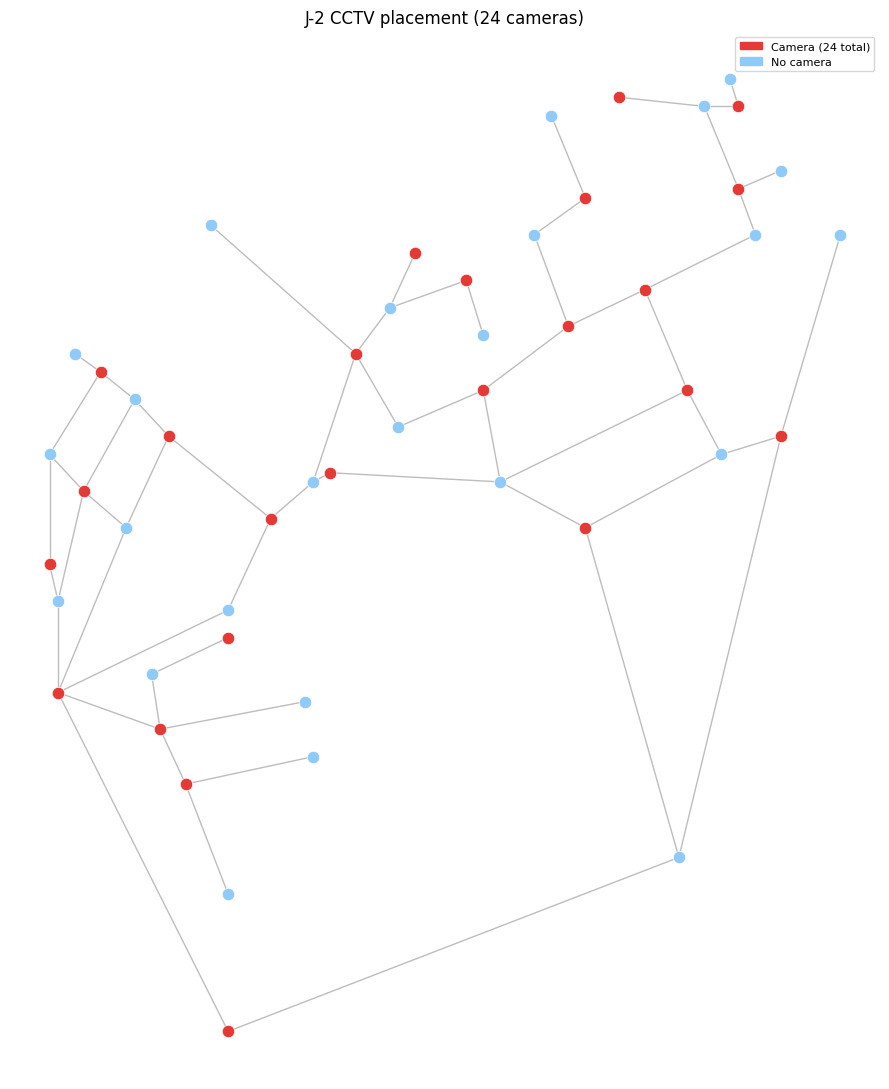

In [ ]:
if "sol_place" in locals():
    # Node positions from original data
    pos_raw = [[30,5],[83,24],[10,42],[22,38],[39,41],[25,32],[40,35],[30,20],[21,44],
               [30,48],[30,51],[10,52],[9,56],[9,68],[13,64],[18,60],[12,79],[15,77],
               [19,74],[23,70],[35,61],[40,65],[42,66],[28,93],[45,79],[49,84],[52,90],
               [58,87],[60,81],[50,71],[60,75],[62,65],[70,82],[66,92],[72,96],[68,105],
               [79,86],[84,75],[72,60],[88,68],[95,70],[102,92],[92,92],[90,97],[86,106],
               [76,107],[90,106],[89,109],[95,99]]
    pos = {n+1: (x, y) for n, (x,y) in enumerate(pos_raw)}

    fig, ax = plt.subplots(figsize=(9, 11))
    # Draw streets
    for n, m in streets:
        x1, y1 = pos[n]; x2, y2 = pos[m]
        ax.plot([x1,x2],[y1,y2], color="#BDBDBD", lw=1, zorder=1)
    # Draw nodes
    for n in range(1, 50):
        x, y = pos[n]
        has_cam = sol_place.get(n, 0) > 0.5
        ax.scatter(x, y, s=80, color="#E53935" if has_cam else "#90CAF9",
                   zorder=2, edgecolors="white", lw=0.5)
    cam_p  = mpatches.Patch(color="#E53935", label=f"Camera ({obj_val_j2:.0f} total)")
    node_p = mpatches.Patch(color="#90CAF9", label="No camera")
    ax.legend(handles=[cam_p, node_p], fontsize=8)
    ax.set_title(f"J-2 CCTV placement ({obj_val_j2:.0f} cameras)")
    ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping surveillance chart")

## J-3 Electoral redistricting (IP)

*Applications Book Chapter J, Example 3*

> **Mosel models:** [`j3elect_mip_p.mos`](models/public_services/j3elect_mip_p.mos) (MIP only, Python preprocessing), [`j3elect_p.mos`](models/public_services/j3elect_p.mos) (original, with data preprocessing in Mosel)

A capital is divided into 14 quarters that must be grouped into 6 electoral districts. Each district must be contiguous (quarters must be adjacent) and have between 30,000 and 100,000 voters. The objective maximizes the number of districts where the target candidate wins a majority.

In this notebook we move the district enumeration **to Python**: a recursive function mirrors the Mosel preprocessing from `j3elect_p.mos`, enumerating all 48 valid districts and computing their majority flags. The resulting `DISTR` and `MAJ` arrays are then passed directly to a compact **MIP-only** Mosel model via `input_data`.

**Sets:** $\text{QUARTERS} = 1..14$, $\text{RDIST} = 1..48$ (all valid districts)

**Parameters:** $\text{POP}_q$, $\text{VOTES}_q$, $\text{MINPOP}$, $\text{MAXPOP}$, $\text{MINSINGLE}$, $\text{REQD}=6$

**Decision variables:** $\mathit{choose}_d \in \{0,1\}$ - 1 if district $d$ is selected

Define the problem data and implement the district enumeration in Python. The `enumerate_districts` function recursively expands quarter sets by adding adjacent neighbors, saving any contiguous set within the population limits as a valid district. It mirrors the Mosel preprocessing in `j3elect_p.mos`, but runs entirely in Python.

In [ ]:
NEIGHB = {
    (1,1):2,(1,2):5,  (2,1):3,(2,2):5,  (3,1):4,(3,2):5,
    (4,1):5,(4,2):10, (5,1):6,(5,2):10, (6,1):7,(6,2):8,
    (7,1):8,(7,2):9,  (8,1):9,(8,2):10,(8,3):11,
    (9,1):11,(9,2):12, (10,1):11,(10,2):13,
    (11,1):12,(11,2):13, (12,1):14, (13,1):14,
}
POP   = {1:30,2:50,3:20,4:70,5:20,6:40,7:30,8:30,9:40,10:60,11:10,12:60,13:40,14:40}
VOTES = {1:17.5,2:15,3:14.2,4:42,5:18,6:9,7:12,8:10,9:26,10:34,11:2.5,12:27,13:29,14:15}
MINPOP, MAXPOP, MINSINGLE, REQD = 30, 100, 50, 6
QUARTERS = range(1, 15)

def enumerate_districts(QUARTERS, NEIGHB, POP, VOTES, MINPOP, MAXPOP, MINSINGLE):
    DISTR, MAJ = {}, {}
    numd = [0]

    def save_distr(sQ):
        numd[0] += 1
        for q in sQ:
            DISTR[(numd[0], q)] = 1

    def add_neighb(toadd, sQ):
        nQ = sQ | {toadd}
        if sum(POP[q] for q in nQ) >= MINPOP:
            save_distr(nQ)
        for idx in range(1, 5):
            p = NEIGHB.get((toadd, idx))
            if p is None: break
            if sum(POP[q] for q in nQ) + POP[p] <= MAXPOP:
                add_neighb(p, nQ)

    for q in QUARTERS:
        if POP[q] >= MINSINGLE and q != 10:
            save_distr({q})
        for idx in range(1, 5):
            p = NEIGHB.get((q, idx))
            if p is None: break
            if POP[q] + POP[p] <= MAXPOP:
                add_neighb(p, {q})

    for d in range(1, numd[0]+1):
        qs = [q for q in QUARTERS if DISTR.get((d,q), 0) > 0]
        pop_d = sum(POP[q] for q in qs); votes_d = sum(VOTES[q] for q in qs)
        MAJ[d] = 1 if votes_d / pop_d >= 0.5 else 0

    return DISTR, MAJ, numd[0]

DISTR_J3, MAJ_J3, NDISTS = enumerate_districts(QUARTERS, NEIGHB, POP, VOTES,
                                                MINPOP, MAXPOP, MINSINGLE)
maj_count = sum(MAJ_J3.values())
print(f"Valid districts enumerated: {NDISTS}")
print(f"Districts with majority: {maj_count}/{NDISTS}")
print(f"Non-zero DISTR entries: {len(DISTR_J3)}")

Valid districts enumerated: 48
Districts with majority: 23/48
Non-zero DISTR entries: 115


Run the MIP-only model `j3elect_mip_p.mos`, passing the Python-computed `DISTR` and `MAJ` arrays via `input_data` together with `NDISTS` via `exec_params`. The model selects the optimal 6 districts without any internal preprocessing.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/j3elect_mip_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:",
                 "NDISTS": NDISTS, "REQD": REQD},
    input_data={"DISTR": DISTR_J3, "MAJ": MAJ_J3},
)

if model.prob_status.is_solution_available:
    obj_val_j3 = output["obj_val"]
    sol_choose = output["sol_choose"]
    distr      = output["DISTR"]
    maj        = output["MAJ"]

    chosen = sorted(d for d, v in sol_choose.items() if v > 0.5)
    print(f"Maximum majority districts: {obj_val_j3:.0f} out of {REQD}")
    print()
    for d in chosen:
        quarters = sorted(q for q in range(1, 15) if distr.get((d, q), 0) > 0.5)
        pop_d    = sum(POP[q] for q in quarters)
        votes_d  = sum(VOTES[q] for q in quarters)
        pct      = 100 * votes_d / pop_d
        win      = "WIN" if maj.get(d, 0) > 0.5 else "lose"
        print(f"  District {d}: quarters {quarters}  pop={pop_d}k  votes={pct:.1f}%  [{win}]")
else:
    print(f"No solution found ({model.prob_status})")

Maximum majority districts: 5 out of 6

  District 3: quarters [1, 2, 5]  pop=100k  votes=50.5%  [WIN]
  District 10: quarters [3, 4]  pop=90k  votes=62.4%  [WIN]
  District 23: quarters [6, 7, 8]  pop=100k  votes=31.0%  [lose]
  District 40: quarters [9, 12]  pop=100k  votes=53.0%  [WIN]
  District 41: quarters [10, 11]  pop=70k  votes=52.1%  [WIN]
  District 48: quarters [13, 14]  pop=80k  votes=55.0%  [WIN]


Bar chart showing vote percentage per chosen district, with winning districts highlighted.

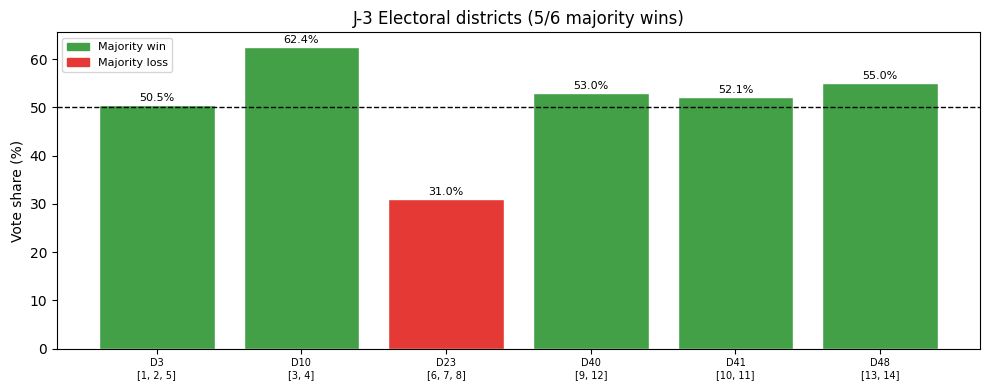

In [ ]:
if "sol_choose" in locals() and model.prob_status.is_solution_available:
    chosen = sorted(d for d, v in sol_choose.items() if v > 0.5)
    pcts   = []
    labels = []
    colors = []
    for d in chosen:
        quarters = [q for q in range(1, 15) if distr.get((d,q), 0) > 0.5]
        pop_d   = sum(POP[q] for q in quarters)
        votes_d = sum(VOTES[q] for q in quarters)
        pct     = 100 * votes_d / pop_d
        pcts.append(pct)
        labels.append(f"D{d}\n{quarters}")
        colors.append("#43A047" if maj.get(d,0) > 0.5 else "#E53935")

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(range(len(chosen)), pcts, color=colors, edgecolor="white")
    ax.axhline(50, color="black", linestyle="--", linewidth=1, label="50% majority")
    for i, (bar, pct) in enumerate(zip(bars, pcts)):
        ax.text(bar.get_x()+bar.get_width()/2, pct+0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(chosen))); ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel("Vote share (%)")
    ax.set_title(f"J-3 Electoral districts ({obj_val_j3:.0f}/{REQD} majority wins)")
    win_p  = mpatches.Patch(color="#43A047", label="Majority win")
    lose_p = mpatches.Patch(color="#E53935", label="Majority loss")
    ax.legend(handles=[win_p, lose_p], fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping electoral chart")

## J-4 Road gritting circuit (LP)

*Applications Book Chapter J, Example 4*

> **Mosel model:** [`j4grit_p.mos`](models/public_services/j4grit_p.mos)

A gritting truck must traverse every street in a village at least once, starting from intersection 1. Streets are directed arcs with given lengths. The model finds the minimum total distance tour (Chinese postman problem).

Decision variables represent arc traversal frequency. Flow balance constraints ensure every intersection is entered as many times as it is exited. After solving, the arc usage dict `sol_use` is returned to Python, which extracts the Eulerian circuit using Hierholzer's algorithm.

**Sets:** $\text{ISEC} = 1..12$

**Parameters:** $\text{LEN}_{i,j}$ - length of street from $i$ to $j$ (sparse)

**Decision variables:** $\mathit{use}_{i,j} \geq 1$ - frequency of traversal of street $(i,j)$

Define street lengths as a sparse dict with `(from, to)` tuple keys. The `LEN` dynamic array auto-extends from the keys; `use` variables are created only for existing streets.

In [ ]:
LEN = {
    (1,2):150,(1,5):165,(2,3):130,(2,5):230,(2,6):160,(3,2):140,
    (3,4):100,(4,3):100,(4,8):190,(5,1):165,(5,6):144,(6,2):170,
    (6,5):144,(6,7):128,(6,9):218,(6,10):174,(7,3):200,(7,6):122,
    (7,8):109,(7,11):185,(8,4):180,(8,11):141,(8,12):190,(9,5):194,
    (9,10):148,(10,6):174,(10,7):233,(11,7):185,(11,10):135,(12,11):110,
}
print(f"Streets: {len(LEN)}")
total_one_pass = sum(LEN.values())
print(f"Total street length (one pass): {total_one_pass}")
print(f"Expected gritting length (with repeats): 5990")

Streets: 30
Total street length (one pass): 4814
Expected gritting length (with repeats): 5990


Use the single execution command. `LEN` is passed as a sparse dict; dynamic arc variables are created only for existing streets. The model returns `obj_val` and `sol_use` (arc traversal frequencies). Python then runs **Hierholzer's algorithm** to extract the Eulerian circuit: starting from intersection 1, the algorithm greedily follows unused edges, inserting sub-tours whenever it finds an intersection with remaining unused edges.

In [ ]:
from collections import defaultdict

def hierholzer(sol_use, start=1):
    adj = defaultdict(list)
    for (i, j), v in sorted(sol_use.items()):
        for _ in range(round(v)):
            adj[i].append(j)
    circuit = []
    stack = [start]
    while stack:
        v = stack[-1]
        if adj[v]:
            stack.append(adj[v].pop(0))
        else:
            circuit.append(stack.pop())
    circuit.reverse()
    return circuit

model, output = mp.execute_model(
    f"{MODELS}/j4grit_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"LEN": LEN},
)

if model.prob_status.is_solution_available:
    obj_val_j4 = output["obj_val"]
    sol_use    = output["sol_use"]

    # Extract Eulerian circuit in Python using Hierholzer's algorithm
    tour_seq = hierholzer(sol_use, start=1)

    print(f"Minimum gritting length: {obj_val_j4:.0f}")
    print()
    repeats = {arc: round(v) - 1 for arc, v in sol_use.items() if round(v) > 1}
    if repeats:
        print("Streets traversed more than once:")
        for (i,j), extra in sorted(repeats.items()):
            print(f"  {i} -> {j}: {extra+1}x (extra {extra})")
    print(f"\nTour ({len(tour_seq)} steps): {' -> '.join(str(n) for n in tour_seq[:10])} ...")
else:
    print(f"No solution found ({model.prob_status})")

Minimum gritting length: 5990

Streets traversed more than once:
  3 -> 4: 2x (extra 1)
  4 -> 8: 2x (extra 1)
  5 -> 1: 2x (extra 1)
  5 -> 6: 2x (extra 1)
  6 -> 9: 2x (extra 1)
  10 -> 6: 2x (extra 1)
  11 -> 7: 2x (extra 1)

Tour (38 steps): 1 -> 2 -> 3 -> 2 -> 5 -> 1 -> 5 -> 6 -> 2 -> 6 ...


Network visualization showing the gritting circuit. Arc thickness reflects traversal frequency; arcs traversed more than once are highlighted.

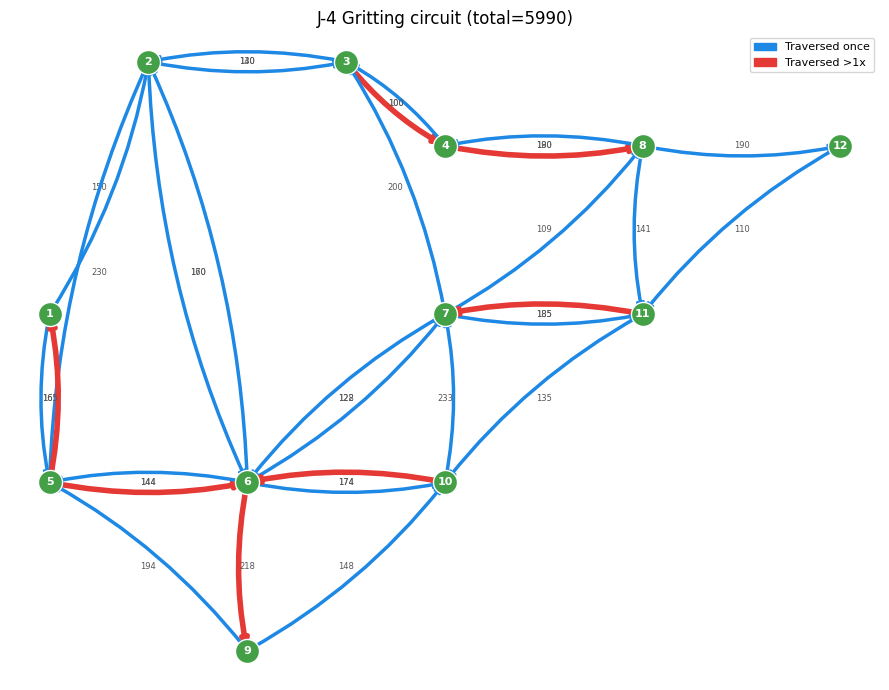

In [ ]:
if "sol_use" in locals():
    # Approximate positions for the 12 intersections
    node_pos = {1:(2,5),2:(3,8),3:(5,8),4:(6,7),5:(2,3),6:(4,3),
                7:(6,5),8:(8,7),9:(4,1),10:(6,3),(11):(8,5),(12):(10,7)}

    fig, ax = plt.subplots(figsize=(9, 7))
    max_use = max(round(v) for v in sol_use.values()) if sol_use else 1

    for (i,j), freq_v in sol_use.items():
        freq = round(freq_v)
        if i not in node_pos or j not in node_pos:
            continue
        x1,y1 = node_pos[i]; x2,y2 = node_pos[j]
        color = "#E53935" if freq > 1 else "#1E88E5"
        lw = 1 + freq * 1.5
        ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle="->", color=color, lw=lw,
                                   connectionstyle="arc3,rad=0.1"))
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my, f"{LEN.get((i,j),0)}", fontsize=6, color="#555",
                ha="center", va="center")

    for n, (x, y) in node_pos.items():
        ax.scatter(x, y, s=300, color="#43A047", zorder=3, edgecolors="white")
        ax.text(x, y, str(n), ha="center", va="center", fontsize=8,
                fontweight="bold", color="white")

    once_p  = mpatches.Patch(color="#1E88E5", label="Traversed once")
    twice_p = mpatches.Patch(color="#E53935", label="Traversed >1x")
    ax.legend(handles=[once_p, twice_p], fontsize=8)
    ax.set_title(f"J-4 Gritting circuit (total={obj_val_j4:.0f})")
    ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping gritting chart")

## J-5 Tax office location (MIP)

*Applications Book Chapter J, Example 5*

> **Mosel model:** [`j5tax_p.mos`](models/public_services/j5tax_p.mos)

Twelve cities are connected by roads. Tax offices must be located in `NUMLOC` of the cities to minimize the total population-weighted travel distance. The model uses Floyd-Warshall to compute all-pairs shortest paths from the sparse road network before solving the MIP.

The Floyd-Warshall preprocessing runs entirely inside Mosel in the same `execute_model` call, with Python only supplying the sparse road lengths and population.

**Sets:** $\text{CITIES} = 1..12$

**Parameters:** $\text{LEN}_{c,d}$ (sparse road lengths), $\text{POP}_c$, $\text{NUMLOC}=3$

**Decision variables:** $\mathit{build}_c \in \{0,1\}$; $\mathit{depend}_{c,d} \geq 0$

Define road lengths as a sparse dict and populations as a 1-indexed dict. `NUMLOC` is set via `exec_params` to demonstrate how the number of offices can be varied from Python without changing the model.

In [ ]:
LEN_J5 = {
    (1,2):15,(1,5):24,(1,7):18,(2,3):22,(3,4):18,(3,5):16,(3,9):20,
    (4,6):12,(5,8):12,(5,9):24,(6,9):12,(6,12):22,(7,8):15,(7,10):22,
    (8,9):30,(8,11):25,(9,11):19,(9,12):19,(10,11):19,(11,12):21,
}
POP_J5 = {1:15,2:10,3:12,4:18,5:5,6:24,7:11,8:16,9:13,10:22,11:19,12:20}
NUMLOC_J5 = 3

total_pop = sum(POP_J5.values())
print(f"Total population: {total_pop}")
print(f"Number of offices to open: {NUMLOC_J5}")
print(f"Road connections: {len(LEN_J5)}")

Total population: 185
Number of offices to open: 3
Road connections: 20


Use the compile-load-run sequence to allow varying `NUMLOC` via `exec_params`. The Floyd-Warshall distance computation runs automatically inside the model before the MIP is solved.

In [ ]:
mp.compile_model(f"{MODELS}/j5tax_p.mos", f"{MODELS}/j5tax_p.bim")
model = mp.load_model(f"{MODELS}/j5tax_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "NUMLOC": NUMLOC_J5},
    input_data={"LEN": LEN_J5, "POP": POP_J5},
)

if model.prob_status.is_solution_available:
    obj_val_j5  = output["obj_val"]
    sol_build   = output["sol_build"]
    sol_depend  = output["sol_depend"]
    dist_matrix = output["DIST"]

    offices = sorted(c for c in range(1, 13) if sol_build.get(c, 0) > 0.5)
    avg_dist = obj_val_j5 / sum(POP_J5.values())

    print(f"Total weighted distance: {obj_val_j5:,.0f}")
    print(f"Average distance per inhabitant: {avg_dist:.2f}")
    print(f"\nOffice locations: {offices}")
    print()
    for office in offices:
        served = sorted(c for c in range(1,13) if sol_depend.get((c,office),0)>0.5)
        print(f"  Office at city {office}: serves cities {served}")
else:
    print(f"No solution found ({model.prob_status})")

Total weighted distance: 2,438
Average distance per inhabitant: 13.18

Office locations: [1, 6, 11]

  Office at city 1: serves cities [1, 2, 5, 7]
  Office at city 6: serves cities [3, 4, 6, 9]
  Office at city 11: serves cities [8, 10, 11, 12]


### Sensitivity analysis: varying number of offices

The model is already compiled. Run with different `NUMLOC` values to see how average travel distance decreases as more offices are added.

In [ ]:
numloc_range = range(1, 7)
sens_results = {}

for nl in numloc_range:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "NUMLOC": nl},
        input_data={"LEN": LEN_J5, "POP": POP_J5},
    )
    if model.prob_status.is_solution_available:
        sens_results[nl] = out["obj_val"] / sum(POP_J5.values())
    else:
        print(f"NUMLOC={nl}: infeasible ({model.prob_status})")

sens_series = pd.Series(sens_results, name="Avg distance per inhabitant")
sens_series.index.name = "Offices"
print("Average distance vs number of offices:")
print(sens_series.apply(lambda v: f"{v:.2f}").to_string())

Average distance vs number of offices:


Offices
1    25.79
2    17.00
3    13.18
4    10.18
5     7.81
6     5.85


Sensitivity curve showing average travel distance per inhabitant as a function of the number of offices opened.

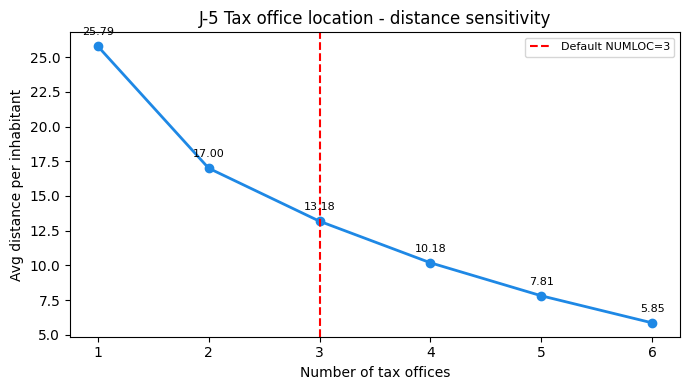

In [ ]:
if sens_series is not None and not sens_series.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sens_series.index, sens_series.values, marker="o", color="#1E88E5", linewidth=2)
    ax.axvline(NUMLOC_J5, color="red", linestyle="--", linewidth=1.5,
               label=f"Default NUMLOC={NUMLOC_J5}")
    for x, y in sens_series.items():
        ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xlabel("Number of tax offices")
    ax.set_ylabel("Avg distance per inhabitant")
    ax.set_title("J-5 Tax office location - distance sensitivity")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No sensitivity data - skipping chart")

## J-6 Hospital efficiency (DEA)

*Applications Book Chapter J, Example 6*

> **Mosel model:** [`j6hospit_p.mos`](models/public_services/j6hospit_p.mos)

Data Envelopment Analysis (DEA) measures the relative efficiency of four hospitals. Each hospital is compared against a fictitious best-practice reference constructed as a convex combination of all hospitals. The efficiency of the reference hospital is minimized subject to matching or exceeding the current hospital's service outputs while staying within its resource inputs.

Named `linctr` constraints (`LimServ`, `LimRes`) are reassigned in-place in each loop iteration to adapt the reference to the hospital being evaluated. All four efficiencies are collected and exported together.

**Sets:** $\text{HOSP} = 1..4$; $\text{SERV}$, $\text{RES}$ (auto-populated)

**Decision variables:** $\mathit{eff}$ - efficiency index; $\mathit{coef}_h \geq 0$ - combination weights; $\mathit{fserv}_s$, $\mathit{fres}_r$ - reference hospital indicators

Define service and resource indicators as 2D dicts with `(indicator_name, hospital)` keys. The `SERV` and `RES` sets auto-populate from the dict keys.

In [ ]:
INDSERV = {
    ("admissions",    1): 30.12, ("admissions",    2): 18.54,
    ("admissions",    3): 20.88, ("admissions",    4): 10.42,
    ("consultations", 1): 13.54, ("consultations", 2): 14.45,
    ("consultations", 3):  8.52, ("consultations", 4): 17.74,
    ("doctors",       1): 13,    ("doctors",       2):  7,
    ("doctors",       3):  8,    ("doctors",       4): 26,
    ("nurses",        1): 79,    ("nurses",        2): 55,
    ("nurses",        3): 47,    ("nurses",        4): 50,
}
INDRES = {
    ("non-med pers", 1): 90,    ("non-med pers", 2): 87,
    ("non-med pers", 3): 51,    ("non-med pers", 4): 66,
    ("expense",      1): 38.89, ("expense",      2): 109.48,
    ("expense",      3): 40.43, ("expense",      4): 48.41,
    ("beds",         1): 34,    ("beds",         2): 33,
    ("beds",         3): 20,    ("beds",         4): 33,
}

hosp_names = {1: "H1", 2: "H2", 3: "H3", 4: "H4"}
serv_names = sorted({s for s, _ in INDSERV})
res_names  = sorted({r for r, _ in INDRES})

serv_df = pd.DataFrame({f"H{h}": {s: INDSERV[(s,h)] for s in serv_names}
                         for h in range(1,5)})
print("Service indicators:")
print(serv_df.to_string())

Service indicators:
                  H1     H2     H3     H4
admissions     30.12  18.54  20.88  10.42
consultations  13.54  14.45   8.52  17.74
doctors        13.00   7.00   8.00  26.00
nurses         79.00  55.00  47.00  50.00


Use the compile-load-run sequence. The model solves DEA for all four hospitals in a single `run()` call, reassigning named `linctr` constraints inside a `forall` loop. The `efficiencies` array (indexed 1..4) is returned as a single output dict entry.

In [ ]:
mp.compile_model(f"{MODELS}/j6hospit_p.mos", f"{MODELS}/j6hospit_p.bim")
model = mp.load_model(f"{MODELS}/j6hospit_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"INDSERV": INDSERV, "INDRES": INDRES},
)

if model.prob_status.is_solution_available:
    efficiencies = output["efficiencies"]

    eff_series = pd.Series(
        {hosp_names[h]: efficiencies.get(h, 0) for h in range(1, 5)},
        name="DEA efficiency",
    )
    print("Hospital efficiency scores (1.0 = fully efficient):")
    print(eff_series.apply(lambda v: f"{v:.4f}").to_string())
    print()
    inefficient = [hosp_names[h] for h in range(1,5) if efficiencies.get(h,1) < 0.9999]
    if inefficient:
        for h in range(1, 5):
            eff = efficiencies.get(h, 1)
            if eff < 0.9999:
                slack = (1 - eff) * 100
                print(f"  {hosp_names[h]}: efficiency {eff:.4f} - could reduce resources by {slack:.1f}%")
    else:
        print("All hospitals are fully efficient.")
else:
    print(f"No solution found ({model.prob_status})")

Hospital efficiency scores (1.0 = fully efficient):
H1    1.0000
H2    0.9210
H3    1.0000
H4    1.0000

  H2: efficiency 0.9210 - could reduce resources by 7.9%


Efficiency bar chart and radar plot comparing service and resource indicators across hospitals.

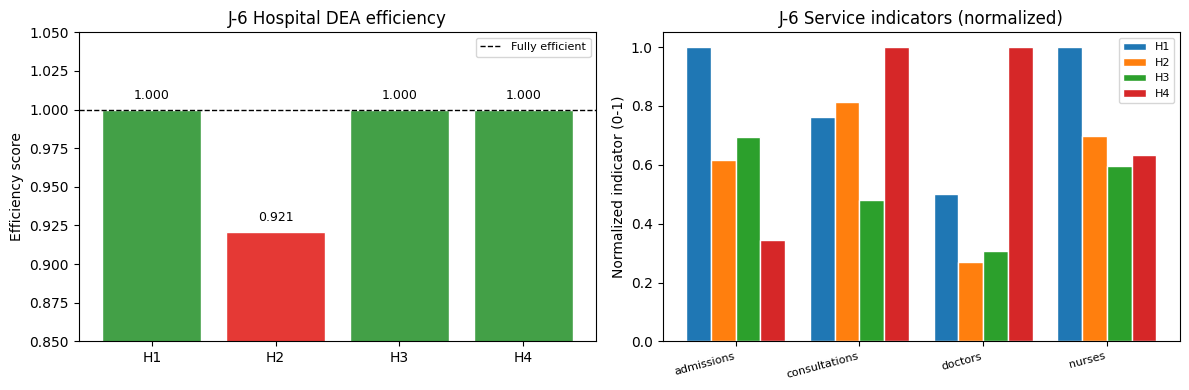

In [ ]:
if "efficiencies" in locals() and model.prob_status.is_solution_available:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: efficiency bar chart
    ax = axes[0]
    eff_vals = [efficiencies.get(h, 0) for h in range(1, 5)]
    colors_eff = ["#43A047" if v > 0.9999 else "#E53935" for v in eff_vals]
    bars = ax.bar([f"H{h}" for h in range(1, 5)], eff_vals, color=colors_eff,
                  edgecolor="white")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Fully efficient")
    for bar, v in zip(bars, eff_vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0.85, 1.05)
    ax.set_ylabel("Efficiency score")
    ax.set_title("J-6 Hospital DEA efficiency")
    ax.legend(fontsize=8)

    # Right: service indicator comparison (normalized)
    ax2 = axes[1]
    serv_display = ["admissions", "consultations", "doctors", "nurses"]
    x = np.arange(len(serv_display))
    width = 0.2
    for i, h in enumerate(range(1, 5)):
        vals = [INDSERV[(s, h)] for s in serv_display]
        max_v = [max(INDSERV[(s, hh)] for hh in range(1,5)) for s in serv_display]
        norm = [v/m for v,m in zip(vals, max_v)]
        ax2.bar(x + i*width - 0.3, norm, width, label=f"H{h}", edgecolor="white")
    ax2.set_xticks(x); ax2.set_xticklabels(serv_display, rotation=15, ha="right", fontsize=8)
    ax2.set_ylabel("Normalized indicator (0-1)")
    ax2.set_title("J-6 Service indicators (normalized)")
    ax2.legend(fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping hospital charts")